In [1]:
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import one_hot
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import pickle
import nltk
import re
from nltk.stem import PorterStemmer
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

c:\Users\mrpar\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
train_data = pd.read_csv("sarcasmdata.txt", header=None, sep=";", names=["Comment", "Emotion"], encoding="utf-8")
train_data['length'] = [len(x) for x in train_data['Comment']]

In [3]:
train_data.head()

,Comment,Emotion,length
0,i didnt feel humiliated,sadness,23
1,i can go from feeling so hopeless to so damned...,sadness,108
2,im grabbing a minute to post i feel greedy wrong,anger,48
3,i am ever feeling nostalgic about the fireplac...,love,92
4,i am feeling grouchy,anger,20


In [4]:
train_data.shape

(16000, 3)

In [5]:
train_data.isnull().sum()

Comment    0
Emotion    0
length     0
dtype: int64

In [6]:
print(train_data.duplicated().sum())

1


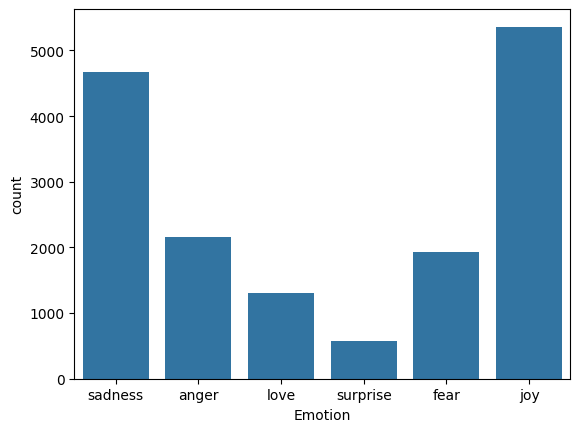

In [7]:
sns.countplot(x = train_data['Emotion'])
plt.show()

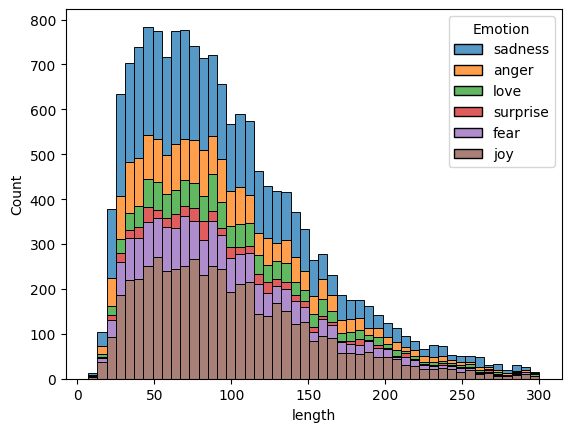

In [8]:
df2 = train_data.copy()
df2['length'] = [len(x) for x in df2['Comment']]
length_values = df2['length'].values
sns.histplot(data=df2, x='length', hue='Emotion', multiple='stack')
plt.show()

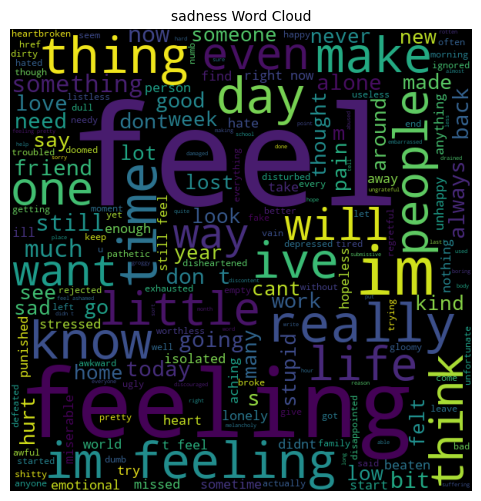

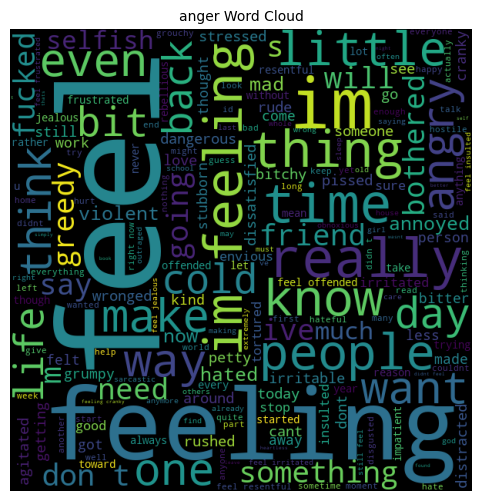

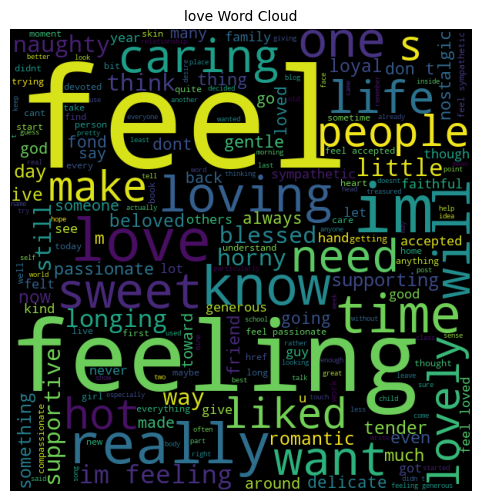

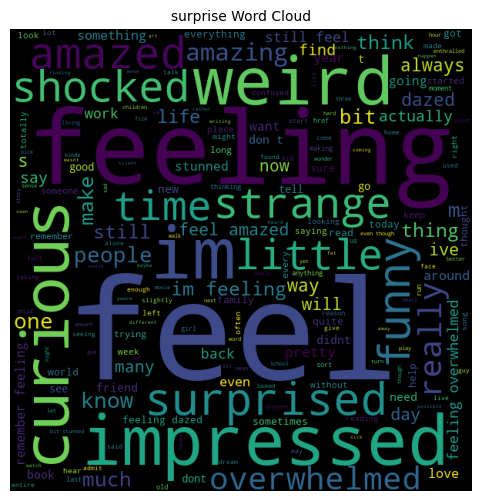

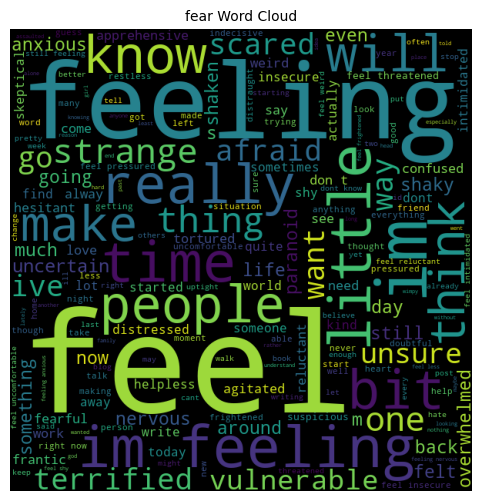

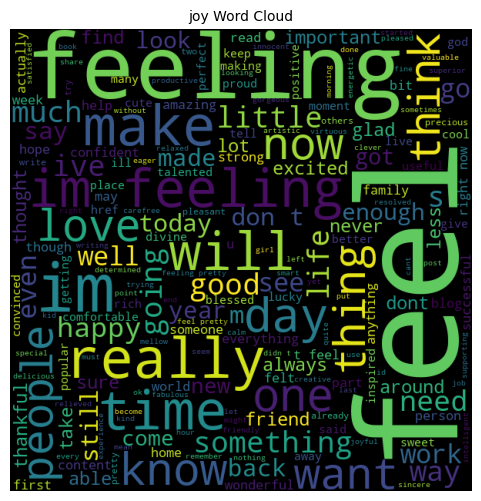

In [9]:
def words_cloud(wordcloud, df):
    plt.figure(figsize=(6, 6))
    plt.title(df+' Word Cloud', size = 10)
    plt.imshow(wordcloud) 
    plt.axis("off");
emotions_list = train_data['Emotion'].unique()
for emotion in emotions_list:
    text = ' '.join([sentence for sentence in train_data.loc[train_data['Emotion'] == emotion,'Comment']])
    wordcloud = WordCloud(width = 600, height = 600).generate(text)
    words_cloud(wordcloud, emotion)

In [10]:
lb = LabelEncoder()
train_data['Emotion_Encoded'] = lb.fit_transform(train_data['Emotion'])
train_data

,Comment,Emotion,length,Emotion_Encoded
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,0
3,i am ever feeling nostalgic about the fireplac...,love,92,3
4,i am feeling grouchy,anger,20,0
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101,4
15996,i am now turning and i feel pathetic that i am...,sadness,102,4
15997,i feel strong and good overall,joy,30,2
15998,i feel like this was such a rude comment and i...,anger,59,0


In [11]:
df = train_data.copy()
df.head()

,Comment,Emotion,length,Emotion_Encoded
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,0
3,i am ever feeling nostalgic about the fireplac...,love,92,3
4,i am feeling grouchy,anger,20,0


In [12]:
nltk.download('stopwords')
stopwords = set(nltk.corpus.stopwords.words('english'))
def clean_text(text):
    stemmer = PorterStemmer()
    text = re.sub("[^a-zA-Z]", " ", text)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stopwords]
    return " ".join(text)
df['cleaned_comment'] = df['Comment'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mrpar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
df.head()

,Comment,Emotion,length,Emotion_Encoded,cleaned_comment
0,i didnt feel humiliated,sadness,23,4,didnt feel humili
1,i can go from feeling so hopeless to so damned...,sadness,108,4,go feel hopeless damn hope around someon care ...
2,im grabbing a minute to post i feel greedy wrong,anger,48,0,im grab minut post feel greedi wrong
3,i am ever feeling nostalgic about the fireplac...,love,92,3,ever feel nostalg fireplac know still properti
4,i am feeling grouchy,anger,20,0,feel grouchi


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [15]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_comment'],df['Emotion_Encoded'],test_size=0.2,random_state=42)

In [16]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [17]:
classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
}
for name, clf in classifiers.items():
    print(f"\n===== {name} =====")
    clf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = clf.predict(X_test_tfidf)
    accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
    print(f"\nAccuracy using TF-IDF: {accuracy_tfidf}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_tfidf))


===== Multinomial Naive Bayes =====

Accuracy using TF-IDF: 0.655
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.31      0.46       427
           1       0.91      0.24      0.38       397
           2       0.58      0.98      0.73      1021
           3       1.00      0.03      0.06       296
           4       0.70      0.91      0.79       946
           5       1.00      0.01      0.02       113

    accuracy                           0.66      3200
   macro avg       0.85      0.41      0.41      3200
weighted avg       0.76      0.66      0.58      3200


===== Logistic Regression =====

Accuracy using TF-IDF: 0.829375
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       427
           1       0.84      0.73      0.78       397
           2       0.78      0.94      0.85      1021
           3       0.80      0.49      0.61       296
       

In [18]:
lg = LogisticRegression()
lg.fit(X_train_tfidf, y_train)
lg_y_pred = lg.predict(X_test_tfidf)

In [19]:
def predict_emotion(input_text):
    cleaned_text = clean_text(input_text)
    input_vectorized = tfidf_vectorizer.transform([cleaned_text])
    predicted_label = lg.predict(input_vectorized)[0]
    predicted_emotion = lb.inverse_transform([predicted_label])[0]
    label =  np.max(lg.predict(input_vectorized))
    return predicted_emotion,label
sentences = [
            "i didnt feel humiliated",
            "i feel strong and good overall",
            "im grabbing a minute to post i feel greedy wrong",
            "He was speechles when he found out he was accepted to this new job",
            "This is outrageous, how can you talk like that?",
            "I feel like im all alone in this world",
            "He is really sweet and caring",
            "You made me very crazy",
            "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
            "i am feeling grouchy",
            "He hates you"
            ]
for sentence in sentences:
    print(sentence)
    pred_emotion, label = predict_emotion(sentence)
    print("Prediction :",pred_emotion)
    print("Label :",label)

i didnt feel humiliated
Prediction : sadness
Label : 4
i feel strong and good overall
Prediction : joy
Label : 2
im grabbing a minute to post i feel greedy wrong
Prediction : anger
Label : 0
He was speechles when he found out he was accepted to this new job
Prediction : joy
Label : 2
This is outrageous, how can you talk like that?
Prediction : anger
Label : 0
I feel like im all alone in this world
Prediction : sadness
Label : 4
He is really sweet and caring
Prediction : love
Label : 3
You made me very crazy
Prediction : sadness
Label : 4
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Prediction : love
Label : 3
i am feeling grouchy
Prediction : anger
Label : 0
He hates you
Prediction : anger
Label : 0


In [20]:
with open("models/logistic_regression/logistic_regression.pkl", "wb") as file:
    pickle.dump(lg, file)
with open("models/logistic_regression/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf_vectorizer, file)
with open("models/logistic_regression/label_encoder.pkl", "wb") as file:
    pickle.dump(lb, file)
print("All files saved successfully")

All files saved successfully


In [21]:
word_lengths = df['cleaned_comment'].apply(lambda x: len(x.split()))
print("Longest comment:", word_lengths.max())

Longest comment: 35


In [ ]:
def text_encoding(df, column, vocab_size, max_len):
    one_hot_word = [one_hot(input_text=text, n=vocab_size) for text in df[column]]
    pad = pad_sequences(sequences=one_hot_word, maxlen=max_len, padding="pre")
    return pad
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
x_train = text_encoding(train_df, "cleaned_comment", vocab_size=11000, max_len=300)
x_val = text_encoding(val_df, "cleaned_comment", vocab_size=11000, max_len=300)
x_test = text_encoding(test_df, "cleaned_comment", vocab_size=11000, max_len=300)
y_train = to_categorical(train_df["Emotion_Encoded"])
y_val = to_categorical(val_df["Emotion_Encoded"])
y_test = to_categorical(test_df["Emotion_Encoded"])

In [27]:
from keras.models import Sequential
model = Sequential()
model.add(Embedding(input_dim=11000, output_dim=150, input_length=300))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(64, activation='sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
callback = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=64, verbose=1, callbacks=[callback])

Epoch 1/10


c:\Users\mrpar\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 68s 325ms/step - accuracy: 0.3620 - loss: 1.5673 - val_accuracy: 0.5562 - val_loss: 1.2747
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 215ms/step - accuracy: 0.7218 - loss: 0.8321 - val_accuracy: 0.8263 - val_loss: 0.5343
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 221ms/step - accuracy: 0.8794 - loss: 0.3766 - val_accuracy: 0.8625 - val_loss: 0.4121
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 241ms/step - accuracy: 0.9183 - loss: 0.2508 - val_accuracy: 0.8656 - val_loss: 0.3870
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 55s 273ms/step - accuracy: 0.9410 - loss: 0.1841 - val_accuracy: 0.8569 - val_loss: 0.4437
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 57s 286ms/step - accuracy: 0.9538 - loss: 0.1415 - val_accuracy: 0.8719 - val_loss: 0.3944


In [28]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8644 - loss: 0.4040
Test Accuracy: 0.8643749952316284


In [29]:
def sentence_cleaning(sentence):
    stemmer = PorterStemmer()
    text = re.sub("[^a-zA-Z]", " ", sentence)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stopwords]
    text = " ".join(text)
    one_hot_word = [one_hot(input_text=text, n=11000)]
    pad = pad_sequences(sequences=one_hot_word, maxlen=300, padding='pre')
    return pad

sentences = [
            "i feel strong and good overall",
            "im grabbing a minute to post i feel greedy wrong",
            "He was speechles when he found out he was accepted to this new job",
            "This is outrageous, how can you talk like that?",
            "I feel like im all alone in this world",
            "He is really sweet and caring",
            "You made me very crazy",
            "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
            "i am feeling grouchy",
            "He hates you"
            ]

for sentence in sentences:
    print(sentence)
    sentence = sentence_cleaning(sentence)
    prediction = model.predict(sentence, verbose=0)
    result = lb.inverse_transform(np.argmax(prediction, axis=-1))[0]
    proba = np.max(prediction)
    print(f"{result} : {proba}\n\n")

i feel strong and good overall
joy : 0.9939256310462952


im grabbing a minute to post i feel greedy wrong
anger : 0.9835532903671265


He was speechles when he found out he was accepted to this new job
joy : 0.7578985095024109


This is outrageous, how can you talk like that?
anger : 0.8756294250488281


I feel like im all alone in this world
sadness : 0.9672060608863831


He is really sweet and caring
love : 0.6704481244087219


You made me very crazy
anger : 0.6201541423797607


i am ever feeling nostalgic about the fireplace i will know that it is still on the property
love : 0.9184367060661316


i am feeling grouchy
anger : 0.939735472202301


He hates you
anger : 0.887394905090332




In [31]:
import os
os.makedirs("models/lstm", exist_ok=True)
model.save("models/lstm/lstm_model.keras")

In [32]:
import pickle
vocab_info = {
    "vocab_size": 11000,
    "max_len": 300
}
with open("models/lstm/vocab_info.pkl", "wb") as file:
    pickle.dump(vocab_info, file)
print("LSTM preprocessing settings saved successfully")

LSTM preprocessing settings saved successfully


In [34]:
with open("models/random_forest/random_forest.pkl", "wb") as file:
    pickle.dump(classifiers["Random Forest"], file)
print("Random Forest model saved successfully")

Random Forest model saved successfully


In [35]:
with open("models/svm/svm.pkl", "wb") as file:
    pickle.dump(classifiers["Support Vector Machine"], file)
print("SVM model saved successfully")

SVM model saved successfully
